In [ ]:
!pip install contextily geopandas  --quiet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import numpy as np
import contextily as ctx

In [ ]:
import gymnasium as gym
from gymnasium import spaces 

In [ ]:

data = pd.read_csv("/content/Received_Traffic_Incident_Calls_20250405.csv")


In [ ]:
data['Longitude'] = data['LOCATION'].str.extract(r'POINT \((-?\d+\.\d+)')[0].astype(float)
data['Latitude'] = data['LOCATION'].str.extract(r'POINT \(-?\d+\.\d+ (\d+\.\d+)\)')[0].astype(float)

print(data[['LOCATION', 'Longitude', 'Latitude']].head(10))


                                        LOCATION  Longitude   Latitude
0    POINT (-78.8814320641978 42.92216312501838) -78.881432  42.922163
1  POINT (-78.83099252029903 42.852545614625306) -78.830993  42.852546
2   POINT (-78.84706559594716 42.90374912858813) -78.847066  42.903749
3  POINT (-78.85073763432342 42.940379128891664) -78.850738  42.940379
4   POINT (-78.89423958059092 42.91157310795572) -78.894240  42.911573
5   POINT (-78.88126552747786 42.89286812255581) -78.881266  42.892868
6   POINT (-78.90222204761716 42.93448412424844) -78.902222  42.934484
7   POINT (-78.87598252554628 42.88449812284196) -78.875983  42.884498
8   POINT (-78.85066114436584 42.94859612908834) -78.850661  42.948596
9   POINT (-78.86832331220701 42.89690543222645) -78.868323  42.896905


In [ ]:


data = data.dropna(subset=['Latitude', 'Longitude'])

geometry = [Point(xy) for xy in zip(data['Longitude'], data['Latitude'])]
geo_data = gpd.GeoDataFrame(data, geometry=geometry)

# defining grid boundaries and resolution
minx, miny, maxx, maxy = geo_data.total_bounds
# approx 1 km x 1 km
grid_size = 0.01  
grid_cells = [box(x, y, x + grid_size, y + grid_size)
              for x in np.arange(minx, maxx, grid_size)
              for y in np.arange(miny, maxy, grid_size)]

# creating grid geodataframe
grid = gpd.GeoDataFrame({'geometry': grid_cells})
grid['grid_id'] = grid.index
grid.set_geometry('geometry', inplace=True)


# spatial join - mapping each accident to a grid cell
joined = gpd.sjoin(geo_data, grid, how='inner', predicate='within')
joined['grid_id'] = joined['index_right']

# defining accident types to calculate probabilities for
accident_types = [
    'ACCIDENT PROPERTY DAMAGE ONLY',
    'ACCIDENT/INJURY',
    'ACCIDENT SKYWAY/33/198'
]

# counting number of accidents of each type per grid cell
accident_counts = joined[joined['Accident Type'].isin(accident_types)]
grouped = accident_counts.groupby(['grid_id', 'Accident Type']).size().reset_index(name='count')
total_counts = grouped.groupby('Accident Type')['count'].sum().reset_index(name='total_count')

# merging totals with individual grid counts and calculate probability
probability_df = pd.merge(grouped, total_counts, on='Accident Type')
probability_df['probability'] = probability_df['count'] / probability_df['total_count']
probability_table = probability_df.pivot(index='grid_id', columns='Accident Type', values='probability').fillna(0)

print(probability_table.head())

Accident Type  ACCIDENT PROPERTY DAMAGE ONLY  ACCIDENT SKYWAY/33/198  \
grid_id                                                                
127                                 0.000007                0.000000   
296                                 0.000314                0.000000   
353                                 0.000061                0.002378   
583                                 0.000007                0.000000   
921                                 0.000007                0.000000   

Accident Type  ACCIDENT/INJURY  
grid_id                         
127                   0.000000  
296                   0.000176  
353                   0.000176  
583                   0.000000  
921                   0.000000  


In [ ]:
print(len(probability_table))

182


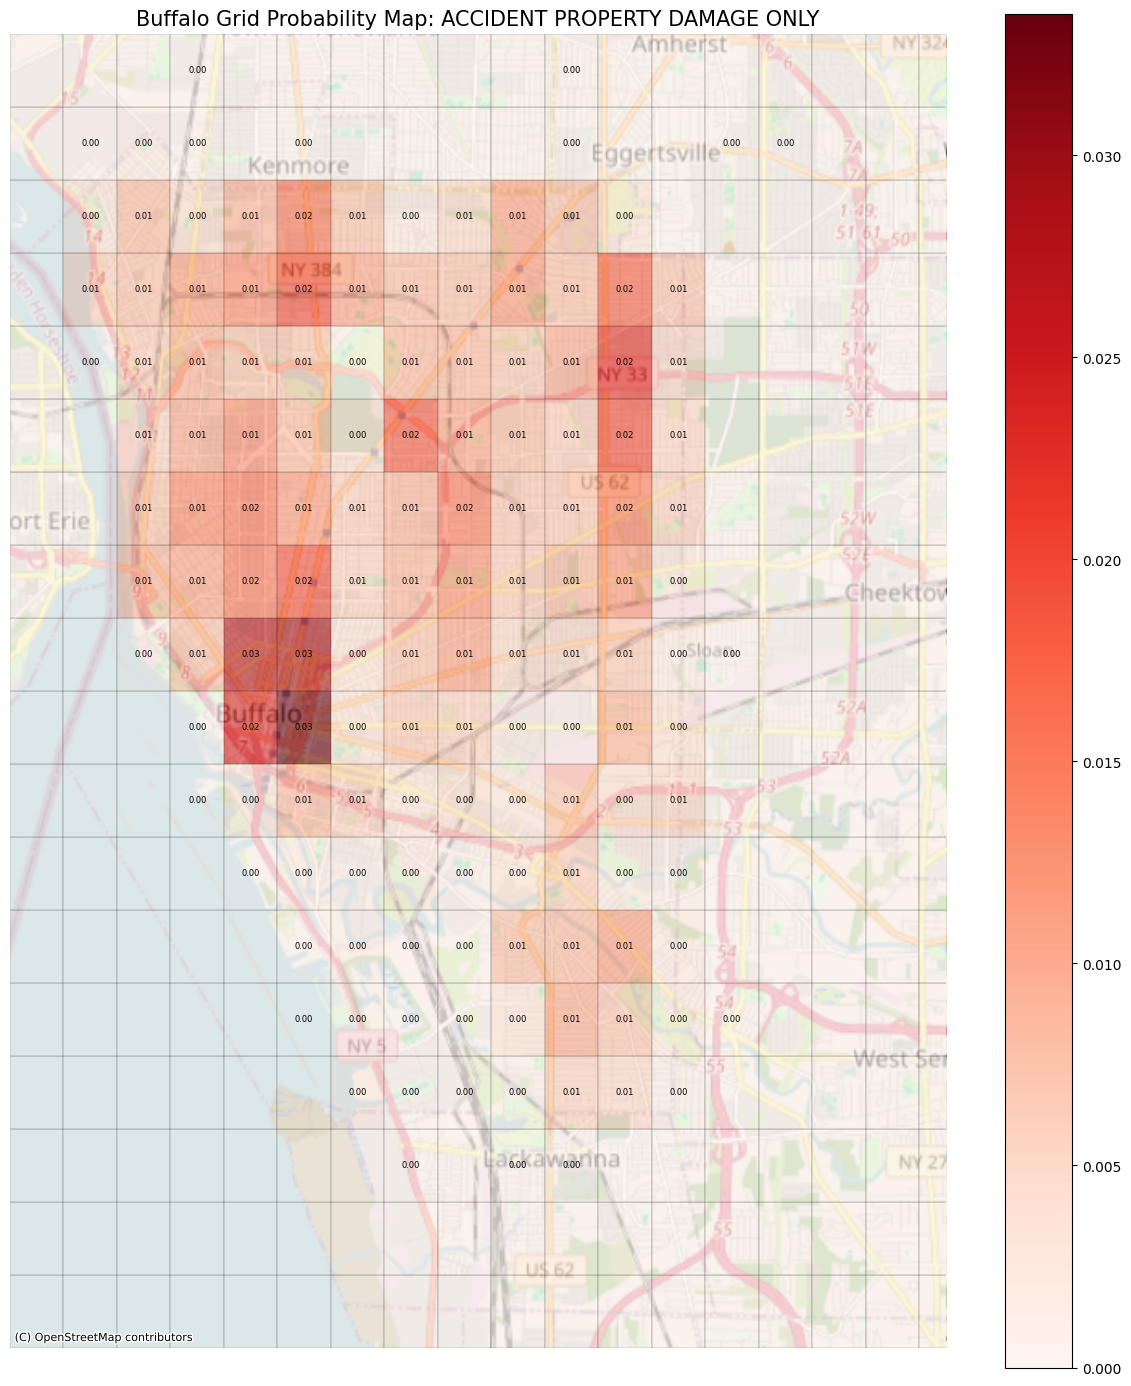

Total sum of probabilities for 'ACCIDENT PROPERTY DAMAGE ONLY': 1.00000


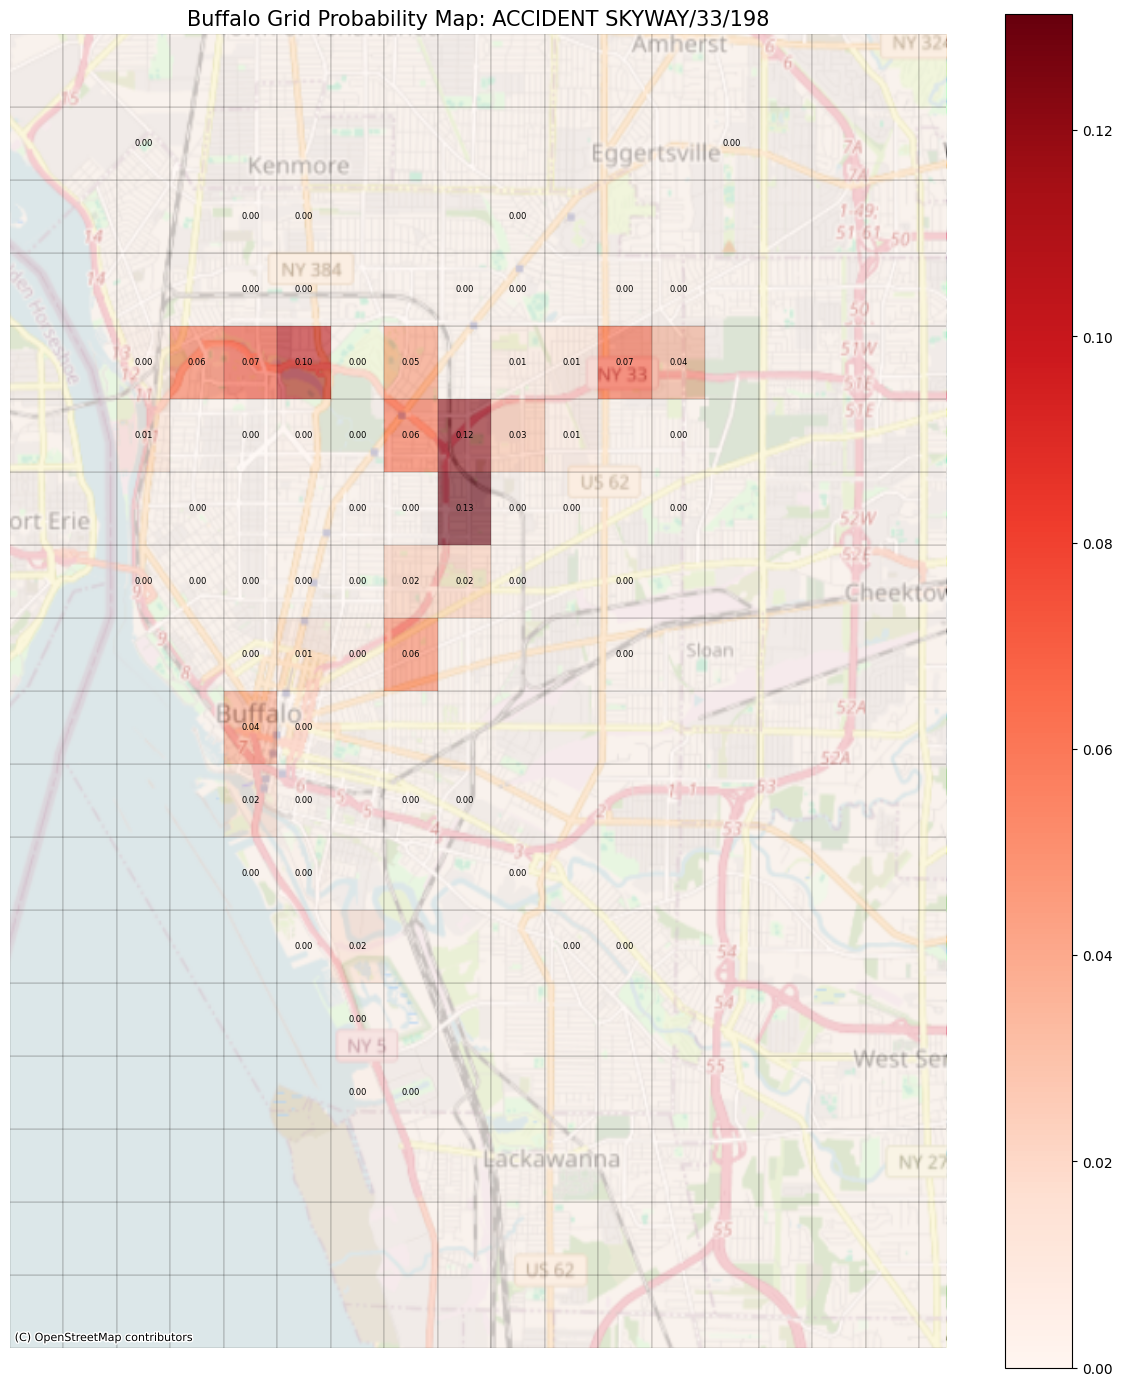

Total sum of probabilities for 'ACCIDENT SKYWAY/33/198': 1.00000


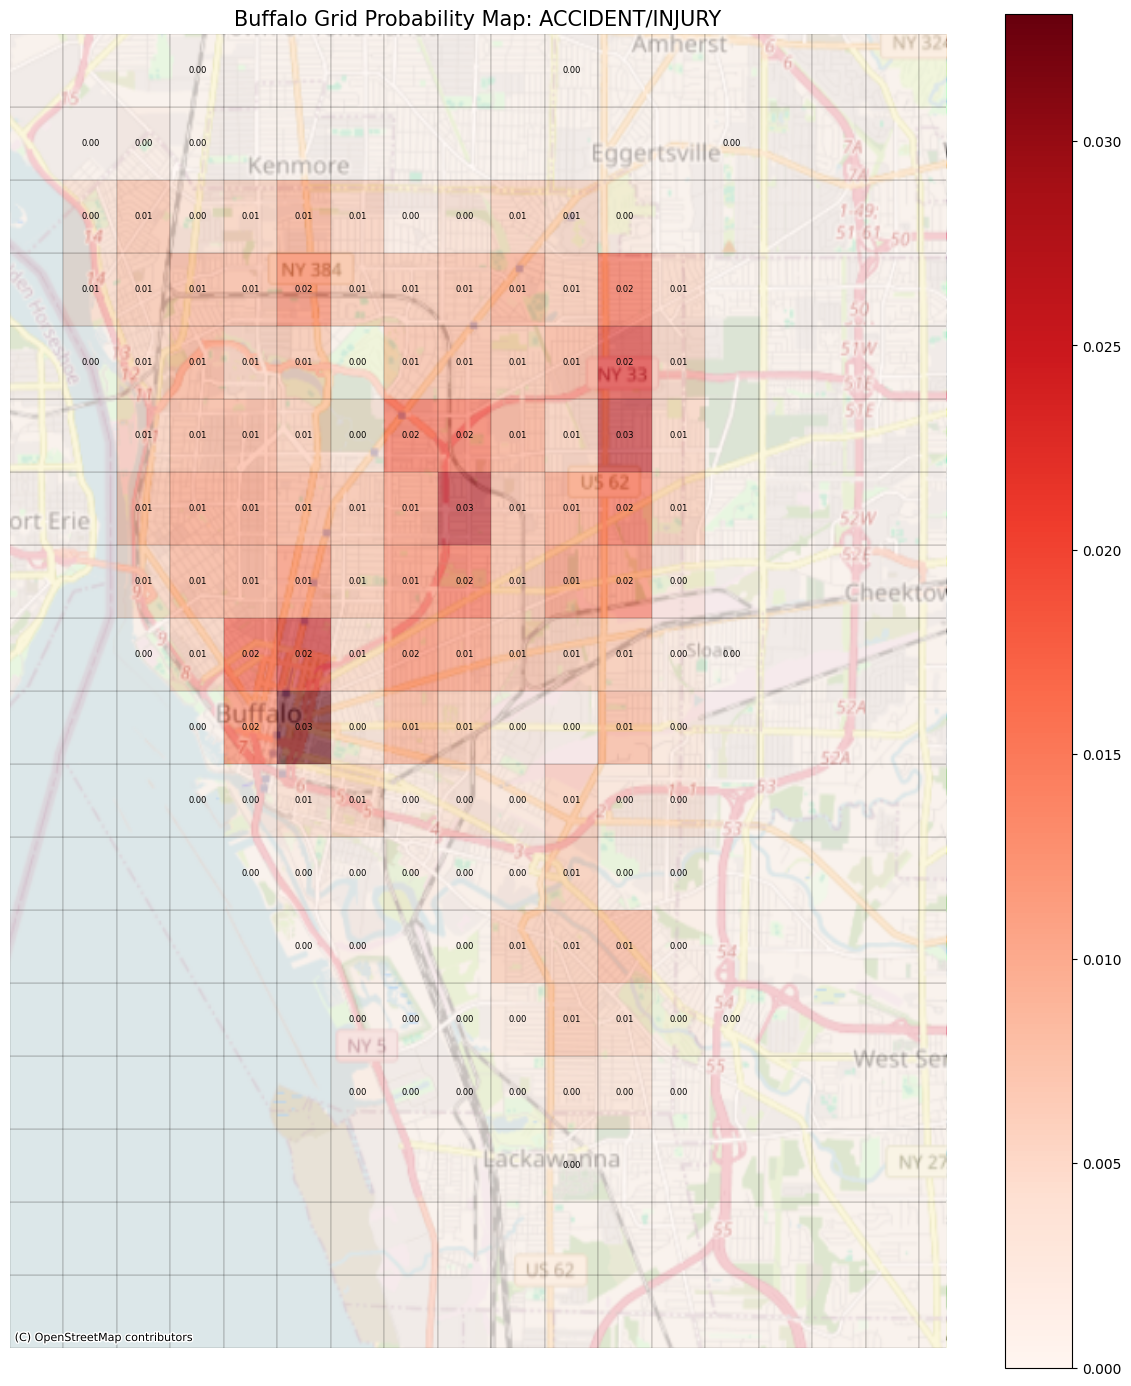

Total sum of probabilities for 'ACCIDENT/INJURY': 1.00000


In [ ]:
geometry = [Point(xy) for xy in zip(data['Longitude'], data['Latitude'])]
geo_data = gpd.GeoDataFrame(data, geometry=geometry, crs='EPSG:4326')

buffalo_bounds = {
    'minx': -78.925,
    'maxx': -78.75,
    'miny': 42.80,
    'maxy': 42.98
}

geo_data = geo_data.cx[buffalo_bounds['minx']:buffalo_bounds['maxx'], buffalo_bounds['miny']:buffalo_bounds['maxy']]

# creating grid
grid_size = 0.01
grid_cells = [
    box(x, y, x + grid_size, y + grid_size)
    for x in np.arange(buffalo_bounds['minx'], buffalo_bounds['maxx'], grid_size)
    for y in np.arange(buffalo_bounds['miny'], buffalo_bounds['maxy'], grid_size)
]
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs='EPSG:4326')
grid['grid_id'] = grid.index

# spatial join
joined = gpd.sjoin(geo_data, grid, how='inner', predicate='within')
joined['grid_id'] = joined['index_right']

# accident types
accident_types = [
    'ACCIDENT PROPERTY DAMAGE ONLY',
    'ACCIDENT/INJURY',
    'ACCIDENT SKYWAY/33/198'
]

# probabilities
accident_counts = joined[joined['Accident Type'].isin(accident_types)]
grouped = accident_counts.groupby(['grid_id', 'Accident Type']).size().reset_index(name='count')
total_counts = grouped.groupby('Accident Type')['count'].sum().reset_index(name='total_count')
probability_df = pd.merge(grouped, total_counts, on='Accident Type')
probability_df['probability'] = probability_df['count'] / probability_df['total_count']
probability_table = probability_df.pivot(index='grid_id', columns='Accident Type', values='probability').fillna(0)

# merging with grid
grid_probs = grid.merge(probability_table, on='grid_id', how='left').fillna(0)

# looping through each accident type in the probability table
for accident_to_plot in probability_table.columns:
    fig, ax = plt.subplots(figsize=(12, 14))

    # plotting grid with accident probabilities
    grid_probs.plot(
        column=accident_to_plot,
        cmap='Reds',
        linewidth=0.2,
        edgecolor='black',
        alpha=0.6,
        legend=True,
        ax=ax
    )

    for idx, row in grid_probs.iterrows():
        prob = row[accident_to_plot]
        if prob > 0:
            centroid = row['geometry'].centroid
            ax.text(centroid.x, centroid.y, f"{prob:.2f}", fontsize=6, ha='center', va='center', color='black')

    ctx.add_basemap(ax, crs=grid_probs.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

    # cropping map tightly to buffalo
    ax.set_xlim(buffalo_bounds['minx'], buffalo_bounds['maxx'])
    ax.set_ylim(buffalo_bounds['miny'], buffalo_bounds['maxy'])

    ax.set_title(f"Buffalo Grid Probability Map: {accident_to_plot}", fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    # printing total probability
    total_prob_sum = grid_probs[accident_to_plot].sum()
    print(f"Total sum of probabilities for '{accident_to_plot}': {total_prob_sum:.5f}")


In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

class ResourceAllocationEnv(gym.Env):
    metadata = {"render_modes": [], "render_fps": 4}

    def __init__(self, probability_data, initial_resources, cell_resource_limits, max_steps=500, reward_config=None):
        super().__init__()

        self.probability_data = probability_data.copy()
        self.num_cells = len(probability_data)
        self.accident_types = list(probability_data.columns)
        self.num_accident_types = len(self.accident_types)

        self.resource_types = list(initial_resources.keys())
        self.num_resource_types = len(self.resource_types)
        self.initial_resources = np.array([initial_resources[res] for res in self.resource_types], dtype=np.int32)
        self.cell_limits = np.array([cell_resource_limits[res] for res in self.resource_types], dtype=np.int32)

        self.max_steps = max_steps
        self.current_step = 0

        self.resource_mapping = {
            'ACCIDENT/INJURY': ['police', 'ambulance'],
            'ACCIDENT PROPERTY DAMAGE ONLY': ['police', 'tow_truck'],
            'ACCIDENT SKYWAY/33/198': ['police', 'ambulance', 'tow_truck']
        }
        self._resource_indices_mapping = {
            acc_type: [self.resource_types.index(res) for res in needed_res]
            for acc_type, needed_res in self.resource_mapping.items()
        }
        self._resource_name_to_index = {name: i for i, name in enumerate(self.resource_types)}

        self.need_thresholds = {
            'ACCIDENT/INJURY': (0.01, 0.02),
            'ACCIDENT PROPERTY DAMAGE ONLY': (0.01, 0.02),
            'ACCIDENT SKYWAY/33/198': (0.03, 0.09)
        }
        self._calculate_need_levels()

        self.reward_config = reward_config or {}

        self.REWARD_WEIGHTS = {
            "correct_match": self.reward_config.get("correct_match", 4.0),
            "incorrect_match": self.reward_config.get("incorrect_match", -4.0),
            "perfect_alloc": self.reward_config.get("perfect_alloc", 2.5),
            "over_alloc": self.reward_config.get("over_alloc", -2.75),
            "smart_realloc": self.reward_config.get("smart_realloc", 1.75),
            "wrong_dealloc": self.reward_config.get("wrong_dealloc", -1.5),
            "conservation_bonus": self.reward_config.get("conservation_bonus", 1.0),
            "no_resource_action_penalty": self.reward_config.get("no_resource_action_penalty", -5.0),
            "over_allocation_action_penalty": self.reward_config.get("over_allocation_action_penalty", -5.0),
            "dealloc_nonexistent_penalty": self.reward_config.get("dealloc_nonexistent_penalty", -1.0),
            "invalid_action_structure_penalty": self.reward_config.get("invalid_action_structure_penalty", -10.0),
        }

        prob_flat_size = self.num_cells * self.num_accident_types
        alloc_flat_size = self.num_cells * self.num_resource_types
        total_res_size = self.num_resource_types
        remain_res_size = self.num_resource_types
        limits_size = self.num_resource_types

        obs_size = prob_flat_size + total_res_size + alloc_flat_size + remain_res_size + limits_size

        low_bounds = np.zeros(obs_size, dtype=np.float32)
        high_bounds = np.concatenate([
            np.ones(prob_flat_size, dtype=np.float32),
            self.initial_resources.astype(np.float32) * 1.1,
            np.tile(self.cell_limits, self.num_cells).astype(np.float32) * 1.1,
            self.initial_resources.astype(np.float32) * 1.1,
            self.cell_limits.astype(np.float32) * 1.1
        ])

        self.observation_space = spaces.Box(low=low_bounds, high=high_bounds, dtype=np.float32)
        self.action_space = spaces.MultiDiscrete([2, self.num_resource_types, self.num_cells])

        self.probabilities_flat = self.probability_data.values.flatten().astype(np.float32)
        self.resources_allocated = np.zeros((self.num_cells, self.num_resource_types), dtype=np.int32)
        self.resources_remaining = self.initial_resources.copy()

    def _calculate_need_levels(self):
        self.need_levels = np.zeros((self.num_cells, self.num_accident_types), dtype=np.int8)
        for i, acc_type in enumerate(self.accident_types):
            probs = self.probability_data[acc_type].values
            med_thresh, high_thresh = self.need_thresholds[acc_type]
            self.need_levels[:, i][probs >= high_thresh] = 2
            self.need_levels[:, i][(probs >= med_thresh) & (probs < high_thresh)] = 1

    def _get_obs(self):
        alloc_flat = self.resources_allocated.flatten().astype(np.float32)
        remain_flat = self.resources_remaining.astype(np.float32)
        total_flat = self.initial_resources.astype(np.float32)
        limits_flat = self.cell_limits.astype(np.float32)

        return np.concatenate([
            self.probabilities_flat, total_flat, alloc_flat, remain_flat, limits_flat
        ]).astype(np.float32)

    def _get_info(self):
        return {
            "step": self.current_step,
            "remaining_resources": self.resources_remaining.copy(),
            "total_allocated": np.sum(self.resources_allocated),
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.resources_allocated = np.zeros((self.num_cells, self.num_resource_types), dtype=np.int32)
        self.resources_remaining = self.initial_resources.copy()
        self.current_step = 0
        return self._get_obs(), self._get_info()

    def step(self, action):
        self.current_step += 1
        reward = 0.0
        terminated = False
        truncated = self.current_step >= self.max_steps

        try:
            action_type, resource_idx, cell_idx = action
            if not (0 <= resource_idx < self.num_resource_types and 0 <= cell_idx < self.num_cells and action_type in [0, 1]):
                raise ValueError("Invalid action indices")
        except (TypeError, ValueError):
            reward += self.REWARD_WEIGHTS["invalid_action_structure_penalty"]
            return self._get_obs(), reward, terminated, truncated, self._get_info()

        if action_type == 0:
            if self.resources_remaining[resource_idx] <= 0:
                reward += self.REWARD_WEIGHTS["no_resource_action_penalty"]
            elif self.resources_allocated[cell_idx, resource_idx] >= self.cell_limits[resource_idx]:
                reward += self.REWARD_WEIGHTS["over_allocation_action_penalty"]
            else:
                self.resources_allocated[cell_idx, resource_idx] += 1
                self.resources_remaining[resource_idx] -= 1
        else:
            if self.resources_allocated[cell_idx, resource_idx] <= 0:
                reward += self.REWARD_WEIGHTS["wrong_dealloc"]
            else:
                self.resources_allocated[cell_idx, resource_idx] -= 1
                self.resources_remaining[resource_idx] += 1
                reward += self.REWARD_WEIGHTS["smart_realloc"]

        reward += self._calculate_state_reward()
        return self._get_obs(), reward, terminated, truncated, self._get_info()

    def _calculate_state_reward(self):
        total_reward = 0.0
        met_grids = 0
        high_med_grids = 0

        for cell_idx in range(self.num_cells):
            cell_alloc = self.resources_allocated[cell_idx, :]
            accident_prob_row = self.probability_data.iloc[cell_idx]
            total_alloc_in_cell = int(np.sum(cell_alloc))

            required_res_set = set()
            for acc_type in self.accident_types:
                prob = accident_prob_row[acc_type]
                if prob > 0.01:
                    res_needed = self.resource_mapping.get(acc_type, [])
                    required_res_set.update(res_needed)

            required_count = len(required_res_set)
            correct_alloc = 0
            incorrect_alloc = 0

            for res_idx, res_name in enumerate(self.resource_types):
                if res_name in required_res_set and cell_alloc[res_idx] > 0:
                    correct_alloc += 1
                elif res_name not in required_res_set and cell_alloc[res_idx] > 0:
                    incorrect_alloc += 1

            if required_count > 0:
                high_med_grids += 1
                if correct_alloc == required_count:
                    met_grids += 1

            total_reward += self.REWARD_WEIGHTS["correct_match"] * correct_alloc
            total_reward += self.REWARD_WEIGHTS["incorrect_match"] * incorrect_alloc

            if total_alloc_in_cell == required_count and required_count > 0:
                total_reward += self.REWARD_WEIGHTS["perfect_alloc"]
            elif total_alloc_in_cell > required_count and required_count > 0:
                total_reward += self.REWARD_WEIGHTS["over_alloc"]

        if high_med_grids > 0:
            met_ratio = met_grids / high_med_grids
            remain_ratio = np.mean(self.resources_remaining / self.initial_resources)
            if met_ratio >= 0.7 and remain_ratio >= 0.1:
                total_reward += self.REWARD_WEIGHTS["conservation_bonus"]

        return total_reward

    def close(self):
        pass


Testing Environment Initialization...
Observation Space: Box(0.0, [ 1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.         1.         1.
  1.         1.         1.        

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import time
import os
import gymnasium as gym
from tqdm.auto import tqdm
import random
from collections import deque, namedtuple


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        """Sample a batch of transitions"""
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# DQN Q-Network
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class DQNNet(nn.Module):
    """
    Q-Network for DQN adapted for MultiDiscrete action space.
    Outputs Q-values for each component of the action space separately.
    """
    def __init__(self, obs_shape, action_dims_nvec):
        super().__init__()
        self.action_dims = action_dims_nvec
        num_action_components = len(action_dims_nvec)
        input_dim = np.prod(obs_shape)

        self.shared_net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.action_type_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.action_dims[0]) # Q-values for action types (alloc/dealloc)
        )
        self.resource_type_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.action_dims[1]) # Q-values for resource types
        )
        self.cell_index_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.action_dims[2]) # Q-values for cell indices
        )

    def forward(self, x):
        """ Returns Q-values for each action component head. """
        shared_features = self.shared_net(x)
        q_action_type = self.action_type_head(shared_features)
        q_resource_type = self.resource_type_head(shared_features)
        q_cell_index = self.cell_index_head(shared_features)
        return q_action_type, q_resource_type, q_cell_index

class DQNAgent:
    def __init__(self, env, buffer_capacity=100_000, batch_size=128, gamma=0.99,
                 eps_start=1.0, eps_end=0.05, eps_decay_steps=200_000, 
                 learning_rate=1e-4, 
                 target_update_freq=1000, 
                 reward_clip_min=-10.0, reward_clip_max=10.0,
                 device=DEVICE):

        self.env = env
        self.obs_shape = env.observation_space.shape
        self.action_dims_nvec = env.action_space.nvec
        self.num_action_components = len(self.action_dims_nvec)
        self.epsilon_history = []
        self.buffer_capacity = buffer_capacity
        self.batch_size = batch_size
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay_steps = eps_decay_steps
        self.learning_rate = learning_rate
        self.target_update_freq = target_update_freq
        self.reward_clip_min = reward_clip_min
        self.reward_clip_max = reward_clip_max
        self.device = device

        if hasattr(env, 'resource_types'): self.resource_types = env.resource_types
        else: self.resource_types = [f"Res_{i}" for i in range(self.action_dims_nvec[1])]

        # networks
        self.policy_net = DQNNet(self.obs_shape, self.action_dims_nvec).to(device)
        self.target_net = DQNNet(self.obs_shape, self.action_dims_nvec).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict()) 
        self.target_net.eval()

        # optimizer and buffer
        self.optimizer = optim.AdamW(self.policy_net.parameters(), lr=self.learning_rate, amsgrad=True)
        self.memory = ReplayBuffer(buffer_capacity)

        self.global_step = 0
        self.current_epsilon = self.eps_start
        self.start_time = time.time()
        self.episode_rewards = []


    def _select_action(self, state):
        """Selects action using exponential epsilon-greedy policy"""

        sample = random.random()

        # compute decay factor once
        decay_factor = (self.eps_end / self.eps_start) ** (1.0 / self.eps_decay_steps)
        self.current_epsilon = max(self.eps_end, self.current_epsilon * decay_factor)

        if sample > self.current_epsilon:
            # exploitation
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
                q_type, q_res, q_cell = self.policy_net(state_tensor)
                action_type = q_type.argmax(1).item()
                action_res = q_res.argmax(1).item()
                action_cell = q_cell.argmax(1).item()
                action = np.array([action_type, action_res, action_cell], dtype=np.int64)
        else:
            # exploration
            action = self.env.action_space.sample()
        return action


    def store_transition(self, state, action, reward, next_state, done):
        """ Stores transition, applying reward clipping """
        reward_clipped = np.clip(reward, self.reward_clip_min, self.reward_clip_max)

        state_np = np.array(state, dtype=np.float32)
        next_state_np = np.array(next_state, dtype=np.float32)
        action_np = np.array(action, dtype=np.int64)
        self.memory.push(state_np, action_np, reward_clipped, next_state_np, float(done))
    def _compute_loss(self):
        """ Computes the DQN loss using a batch from the replay buffer """
        if len(self.memory) < self.batch_size:
            return None
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        state_batch = torch.tensor(np.array(batch.state), dtype=torch.float32, device=self.device)
        # action batch shape - [batch_size, num_components]
        action_batch = torch.tensor(np.array(batch.action), dtype=torch.long, device=self.device)
        reward_batch = torch.tensor(batch.reward, dtype=torch.float32, device=self.device)
        next_state_batch = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=self.device)
        done_batch = torch.tensor(batch.done, dtype=torch.float32, device=self.device) # 1 if done, 0 otherwise
        q_type_all, q_res_all, q_cell_all = self.policy_net(state_batch)

        # selecting the q value for the specific action component taken
        q_type_taken = q_type_all.gather(1, action_batch[:, 0].unsqueeze(1)).squeeze(1)
        q_res_taken = q_res_all.gather(1, action_batch[:, 1].unsqueeze(1)).squeeze(1)
        q_cell_taken = q_cell_all.gather(1, action_batch[:, 2].unsqueeze(1)).squeeze(1)

        # Combining the q values for the chosen action components (e.g., sum or average)
        current_q_values = q_type_taken + q_res_taken + q_cell_taken

        # calculating target q values using double DQN
        with torch.no_grad():
            #  Select best next action components using the policy network
            next_q_type_policy, next_q_res_policy, next_q_cell_policy = self.policy_net(next_state_batch)
            best_next_action_type = next_q_type_policy.argmax(1).unsqueeze(1)
            best_next_action_res = next_q_res_policy.argmax(1).unsqueeze(1)  
            best_next_action_cell = next_q_cell_policy.argmax(1).unsqueeze(1) 

            # evaluating these best next actions using the target network
            next_q_type_target, next_q_res_target, next_q_cell_target = self.target_net(next_state_batch)

            # gathering the target q values corresponding to the best action components chosen by the policy net
            target_q_next_type = next_q_type_target.gather(1, best_next_action_type).squeeze(1)
            target_q_next_res = next_q_res_target.gather(1, best_next_action_res).squeeze(1)
            target_q_next_cell = next_q_cell_target.gather(1, best_next_action_cell).squeeze(1)

            # combining the target q values for the chosen next action 
            target_q_next_combined = target_q_next_type + target_q_next_res + target_q_next_cell

            # calculating the final target value
            target_q_values = reward_batch + self.gamma * target_q_next_combined * (1.0 - done_batch)

        # loss = F.smooth_l1_loss(current_q_values, target_q_values) # Huber loss
        loss = F.mse_loss(current_q_values, target_q_values) # Mean Squared Error loss

        return loss

    def _update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def update(self):
        loss = self._compute_loss()
        if loss is not None:
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
            self.optimizer.step()
            return loss.item()
        return None

    def train(self, total_timesteps, update_after_steps=1000, update_every_steps=4):
        print(f"Starting DQN training for {total_timesteps} timesteps ")
        print(f"Buffer Capacity: {self.buffer_capacity}, Batch Size: {self.batch_size}")
        print(f"Epsilon Decay Steps: {self.eps_decay_steps}, Target Update Freq: {self.target_update_freq}")
        print(f"Reward Clipping: [{self.reward_clip_min}, {self.reward_clip_max}]")

        obs, _ = self.env.reset()
        current_episode_reward = 0
        last_log_step = 0
        pbar = tqdm(total=total_timesteps, desc="Training Timesteps", unit="step")
        losses = []
        while self.global_step < total_timesteps:
            self.global_step += 1
            pbar.update(1)
            self.epsilon_history.append(self.current_epsilon)

            # selecting action
            action = self._select_action(obs)

            # interacting with environment
            next_obs, reward_original, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated

            # storing transition (with clipped reward)
            self.store_transition(obs, action, reward_original, next_obs, done)

            obs = next_obs
            current_episode_reward += reward_original

            # performing network update
            if self.global_step > update_after_steps and self.global_step % update_every_steps == 0:
                loss_val = self.update()
                if loss_val is not None:
                    losses.append(loss_val)

            # updating target network
            if self.global_step % self.target_update_freq == 0:
                self._update_target_network()

            # logging
            if self.global_step % 1000 == 0:
                avg_reward_100_orig = np.mean(self.episode_rewards[-100:]) if self.episode_rewards else 0
                avg_loss_100 = np.mean(losses[-100:]) if losses else 0
                elapsed_time = time.time() - self.start_time
                steps_per_sec = self.global_step / elapsed_time if elapsed_time > 0 else 0

                action_type_str = "Alloc" if action[0] == 0 else "Dealloc"
                resource_idx = int(action[1])
                resource_str = self.resource_types[resource_idx] if 0 <= resource_idx < len(self.resource_types) else f"InvalidRes({resource_idx})"
                cell_str = f"Cell {int(action[2])}"
                formatted_action = f"{action_type_str} {resource_str} @ {cell_str}"
                remaining_res = info.get('remaining_resources', {})

                pbar.set_postfix({
                    "Avg Rew": f"{avg_reward_100_orig:.2f}",
                    "Avg Loss": f"{avg_loss_100:.3f}",
                    "Epsilon": f"{self.current_epsilon:.3f}",
                    "SPS": f"{steps_per_sec:.0f}"
                })

                if self.global_step - last_log_step >= 5000:
                     print(f"\n Log @ Timestep {self.global_step}/{total_timesteps} ")
                     print(f"  Avg ORIGINAL Reward (Last 100 Eps): {avg_reward_100_orig:.3f}")
                     print(f"  Avg Loss (Last 100 Updates): {avg_loss_100:.4f}")
                     print(f"  Current Epsilon: {self.current_epsilon:.4f}")
                     print(f"  Buffer Size: {len(self.memory)} / {self.buffer_capacity}")
                     print(f"  Last Action: {formatted_action} (Raw: {action})")
                     print(f"  Remaining Resources: {remaining_res}")
                     last_log_step = self.global_step

            if done:
                self.episode_rewards.append(current_episode_reward)
                current_episode_reward = 0
                obs, _ = self.env.reset()

        pbar.close()
        print("Training finished.")
        plt.figure(figsize=(8, 4))
        plt.plot(self.epsilon_history)
        plt.title("Epsilon Decay Over Time")
        plt.xlabel("Timestep")
        plt.ylabel("Epsilon")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("epsilon_decay_curve.png")  
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(self.episode_rewards)
        plt.title("Rewards per Episode")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("rewards_per_episode.png")
        plt.show()

        return self.policy_net


        def save(self, path="dqn_resource_allocator.pth"):
            os.makedirs(os.path.dirname(path), exist_ok=True)
            try:
                save_data = {
                    "model_state_dict": self.policy_net.state_dict(),
                    "episode_rewards": self.episode_rewards,
                    "epsilon_history": self.epsilon_history
                }
                torch.save(save_data, path)
                print(f"DQN Policy Network and training data saved to {path}")
            except Exception as e:
                print(f"Error saving DQN model to {path}: {e}")


        def load(self, path="dqn_resource_allocator.pth"):
            if os.path.exists(path):
                try:
                    checkpoint = torch.load(path, map_location=self.device)
                    self.policy_net.load_state_dict(checkpoint["model_state_dict"])
                    self.target_net.load_state_dict(self.policy_net.state_dict())
                    self.policy_net.to(self.device)
                    self.target_net.to(self.device)
                    self.target_net.eval()

                    self.episode_rewards = checkpoint.get("episode_rewards", [])
                    self.epsilon_history = checkpoint.get("epsilon_history", [])
                    print(f"DQN Policy Network and training data loaded from {path}")
                except Exception as e:
                    print(f"Error loading DQN model from {path}: {e}")
            else:
                print(f"Warning: DQN Model file not found at {path}. Starting with untrained model.")


if __name__ == '__main__':

    print(f"Using probability table with shape: {probability_table.shape}")

    initial_resources = {'police': 50, 'ambulance': 50, 'tow_truck': 50}
    cell_resource_limits = {'police': 3, 'ambulance': 2, 'tow_truck': 2}
    max_episode_steps = 2000

    reward_config = {
        "met_need_reward": 1.5, "unmet_need_penalty": -2.0,
        "met_need_factor": {0: 0.0, 1: 1.2, 2: 2.5}, "unmet_need_factor": {0: 0.0, 1: 1.2, 2: 3.0},
        "wrong_allocation_penalty": -0.5, "over_allocation_action_penalty": -1.0,
        "no_resource_action_penalty": -1.0, "dealloc_nonexistent_penalty": -0.2,
        "invalid_action_structure_penalty": -5.0,
    }
    print(f"Using Reward Config: {reward_config}")

    env = ResourceAllocationEnv(
        probability_data=probability_table, initial_resources=initial_resources,
        cell_resource_limits=cell_resource_limits, max_steps=max_episode_steps,
        reward_config=reward_config
    )
    print(f"Environment created. Obs: {env.observation_space.shape}, Act (nvec): {env.action_space.nvec}")

    dqn_config = {
        "buffer_capacity": 50_000,   
        "batch_size": 128,           
        "gamma": 0.99,
        "eps_start": 0.9,            
        "eps_end": 0.05,          
        "eps_decay_steps": 150_000,  
        "learning_rate": 1e-4,       
        "target_update_freq": 1000, 
        "reward_clip_min": -10.0,    
        "reward_clip_max": 10.0,
        "device": DEVICE
    }
    print(f"DQN Config: {dqn_config}")

    total_training_timesteps = 5_000_000 
    update_after_steps = 5000       
    update_every_steps = 4          
    model_save_path = "dqn_buffalo_allocator.pth"

    # creating the DQN agent instance
    agent = DQNAgent(env, **dqn_config)


    # agent.load(model_save_path)

    trained_policy_net = agent.train(
        total_timesteps=total_training_timesteps,
        update_after_steps=update_after_steps,
        update_every_steps=update_every_steps
    )

    agent.save(model_save_path)
    print("\n Evaluating trained DQN agent ")
    eval_episodes = 10
    total_eval_reward = 0
    all_final_infos = []

    # ensuring the agent uses the trained policy net for evaluation
    eval_policy_net = agent.policy_net
    eval_policy_net.eval()

    for i in range(eval_episodes):
        obs, info = env.reset()
        done = False
        episode_reward = 0
        step = 0
        while not done:
            with torch.no_grad():
                # using deterministic actions for evaluation 
                state_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                q_type, q_res, q_cell = eval_policy_net(state_tensor)
                action_type = q_type.argmax(1).item()
                action_res = q_res.argmax(1).item()
                action_cell = q_cell.argmax(1).item()
                action_np = np.array([action_type, action_res, action_cell], dtype=np.int64)

            obs, reward, terminated, truncated, info = env.step(action_np)
            done = terminated or truncated
            episode_reward += reward
            step +=1
        print(f"Eval Episode {i+1} | Reward: {episode_reward:.2f} | Steps: {step}")
        all_final_infos.append(info)
        total_eval_reward += episode_reward

    avg_eval_reward = total_eval_reward / eval_episodes
    print(f"\nAverage Evaluation Reward ({eval_episodes} episodes): {avg_eval_reward:.2f}")

    avg_remaining = {res: np.mean([info_item.get('remaining_resources', {}).get(res, 0)
                                   for info_item in all_final_infos if isinstance(info_item, dict)])
                     for res in initial_resources}
    print(f"Average Remaining Resources after Eval: {avg_remaining}")

    env.close()
    print(" Script Finished ")

Using device: cuda
Using probability table with shape: (145, 3)
Using Reward Config: {'met_need_reward': 1.5, 'unmet_need_penalty': -2.0, 'met_need_factor': {0: 0.0, 1: 1.2, 2: 2.5}, 'unmet_need_factor': {0: 0.0, 1: 1.2, 2: 3.0}, 'wrong_allocation_penalty': -0.5, 'over_allocation_action_penalty': -1.0, 'no_resource_action_penalty': -1.0, 'dealloc_nonexistent_penalty': -0.2, 'invalid_action_structure_penalty': -5.0}
Environment created. Obs: (879,), Act (nvec): [  2   3 145]
DQN Config: {'buffer_capacity': 50000, 'batch_size': 128, 'gamma': 0.99, 'eps_start': 0.9, 'eps_end': 0.05, 'eps_decay_steps': 150000, 'learning_rate': 0.0001, 'target_update_freq': 1000, 'reward_clip_min': -10.0, 'reward_clip_max': 10.0, 'device': device(type='cuda')}
Starting DQN training for 5000000 timesteps...
Buffer Capacity: 50000, Batch Size: 128
Epsilon Decay Steps: 150000, Target Update Freq: 1000
Reward Clipping: [-10.0, 10.0]


Training Timesteps:   0%|          | 0/5000000 [00:00<?, ?step/s]

Streaming output truncated to the last 5000 lines.
  Buffer Size: 50000 / 50000
  Last Action: Alloc police @ Cell 5 (Raw: [0 0 5])
  Remaining Resources: [45 50 46]
--------------------------------------------------

--- Log @ Timestep 2230000/5000000 ---
  Avg ORIGINAL Reward (Last 100 Eps): -47712.640
  Avg Loss (Last 100 Updates): 1285.9925
  Current Epsilon: 0.0500
  Buffer Size: 50000 / 50000
  Last Action: Alloc police @ Cell 99 (Raw: [ 0  0 99])
  Remaining Resources: [47 48 47]
--------------------------------------------------

--- Log @ Timestep 2235000/5000000 ---
  Avg ORIGINAL Reward (Last 100 Eps): -47681.227
  Avg Loss (Last 100 Updates): 1146.3810
  Current Epsilon: 0.0500
  Buffer Size: 50000 / 50000
  Last Action: Alloc ambulance @ Cell 63 (Raw: [ 0  1 63])
  Remaining Resources: [49 46 43]
--------------------------------------------------

--- Log @ Timestep 2240000/5000000 ---
  Avg ORIGINAL Reward (Last 100 Eps): -47701.402
  Avg Loss (Last 100 Updates): 1074.897

FileNotFoundError: [Errno 2] No such file or directory: ''

In [ ]:
import os

model_save_path = "models/dqn_buffalo.pth"
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

agent.save(model_save_path)


DQN Policy Network saved to models/dqn_buffalo.pth


Evaluation Episode 1: Reward = -47577.00
Evaluation Episode 2: Reward = -47577.00
Evaluation Episode 3: Reward = -47577.00
Evaluation Episode 4: Reward = -47577.00
Evaluation Episode 5: Reward = -47577.00
Evaluation Episode 6: Reward = -47577.00
Evaluation Episode 7: Reward = -47577.00
Evaluation Episode 8: Reward = -47577.00
Evaluation Episode 9: Reward = -47577.00
Evaluation Episode 10: Reward = -47577.00


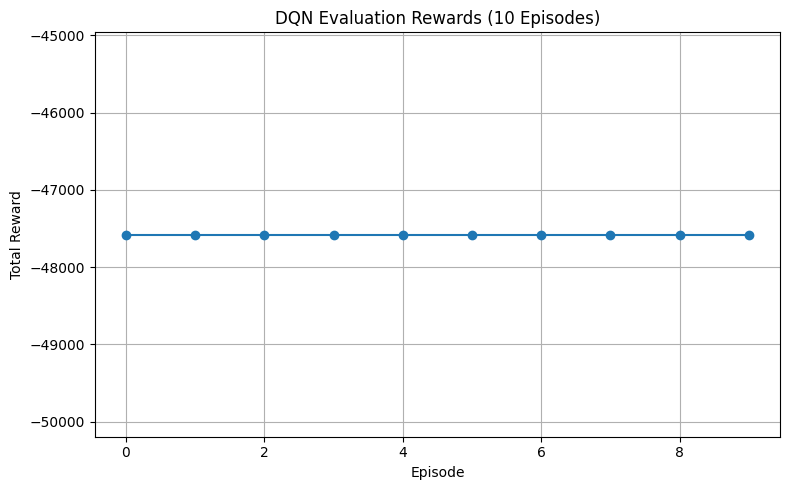


Average Reward over 10 Episodes: -47577.00


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# loading model weights
agent.policy_net.load_state_dict(torch.load("models/dqn_buffalo.pth"))
agent.policy_net.eval()

eval_rewards = []

for ep in range(10):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        with torch.no_grad():
            state_array = np.ravel(state).astype(np.float32)
            state_tensor = torch.tensor(state_array).unsqueeze(0).to(agent.device)
            q_values = agent.policy_net(state_tensor)

            # if the output is a tuple, get the first element
            if isinstance(q_values, tuple):
                q_values = q_values[0]


        action = torch.argmax(q_values, dim=1).item()


        action_multi = np.unravel_index(action, env.action_space.nvec)
        next_state, reward, terminated, truncated, _ = env.step(action_multi)
        done = terminated or truncated
        state = next_state
        total_reward += reward

    eval_rewards.append(total_reward)
    print(f"Evaluation Episode {ep + 1}: Reward = {total_reward:.2f}")

# plot
plt.figure(figsize=(8, 5))
plt.plot(eval_rewards, marker='o')
plt.title("DQN Evaluation Rewards (10 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

# average reward
avg = np.mean(eval_rewards)
print(f"\nAverage Reward over 10 Episodes: {avg:.2f}")


In [ ]:
import folium
from folium.features import GeoJsonTooltip
import geopandas as gpd

def visualize_allocations_on_folium(grid, allocations, map_center=[42.8864, -78.8784]):
    import folium
    from folium.features import GeoJsonTooltip

    m = folium.Map(location=map_center, zoom_start=12, tiles='cartodbpositron')

    # adding grid overlay
    folium.GeoJson(
        grid.to_json(),
        name="Grid",
        style_function=lambda x: {
            'fillColor': '#00000000',
            'color': '#888',
            'weight': 0.5
        },
        tooltip=GeoJsonTooltip(fields=['grid_id'])
    ).add_to(m)

    # plotting allocations
    for grid_id, alloc in allocations.items():
        geom = grid.loc[grid_id, 'geometry']
        center = geom.centroid
        lat, lon = center.y, center.x

        total = sum(alloc.values())
        popup = f"Grid {grid_id}<br>" + "<br>".join([f"{k}: {v}" for k, v in alloc.items()])
        color = 'green' if total > 0 else 'red'

        folium.CircleMarker(
            location=[lat, lon],
            radius=6 + total,
            color=color,
            fill=True,
            fill_opacity=0.6,
            popup=popup
        ).add_to(m)

    folium.LayerControl().add_to(m)
    return m


In [ ]:
m = visualize_allocations_on_folium(
    grid=grid,                             
    allocations=env.state['allocations']  
)
m.save('agent_allocations_map.html')
m


AttributeError: 'ResourceAllocationEnv' object has no attribute 'state'

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.features import GeoJsonTooltip

# evaluation 
agent.policy_net.load_state_dict(torch.load("models/dqn_buffalo.pth"))
agent.policy_net.eval()

eval_rewards = []
last_allocations = None  

for ep in range(10):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        with torch.no_grad():
            state_array = np.ravel(state).astype(np.float32)
            state_tensor = torch.tensor(state_array).unsqueeze(0).to(agent.device)

            q_values = agent.policy_net(state_tensor)
            if isinstance(q_values, tuple):
                q_values = q_values[0]

            action = torch.argmax(q_values, dim=1).item()

        action_multi = np.unravel_index(action, env.action_space.nvec)
        next_state, reward, terminated, truncated, _ = env.step(action_multi)
        done = terminated or truncated
        state = next_state
        total_reward += reward

        # trying to capture allocations from environment
        if hasattr(env, "allocations"):
            last_allocations = env.allocations
        elif hasattr(env, "current_allocations"):
            last_allocations = env.current_allocations
        elif isinstance(state, dict) and "allocations" in state:
            last_allocations = state["allocations"]

    eval_rewards.append(total_reward)
    print(f"Evaluation Episode {ep + 1}: Reward = {total_reward:.2f}")

# average reward
avg = np.mean(eval_rewards)
print(f"\nAverage Reward over 10 Episodes: {avg:.2f}")

# visualization 
def visualize_allocations_on_folium(grid, allocations, map_center=[42.8864, -78.8784]):
    m = folium.Map(location=map_center, zoom_start=12, tiles='cartodbpositron')

    # adding grid overlay
    folium.GeoJson(
        grid.to_json(),
        name="Grid",
        style_function=lambda x: {
            'fillColor': '#00000000',
            'color': '#888',
            'weight': 0.5
        },
        tooltip=GeoJsonTooltip(fields=['grid_id'])
    ).add_to(m)

    # plotingt resource allocations
    for grid_id, alloc in allocations.items():
        geom = grid.loc[grid_id, 'geometry']
        center = geom.centroid
        lat, lon = center.y, center.x

        total = sum(alloc.values())
        popup = f"Grid {grid_id}<br>" + "<br>".join([f"{k}: {v}" for k, v in alloc.items()])
        color = 'green' if total > 0 else 'red'

        folium.CircleMarker(
            location=[lat, lon],
            radius=6 + total,
            color=color,
            fill=True,
            fill_opacity=0.6,
            popup=popup
        ).add_to(m)

    folium.LayerControl().add_to(m)
    return m
# checking for allocation related attributes in the environment
print("Checking env for any allocation-related attributes ")
print([attr for attr in dir(env) if 'alloc' in attr.lower()])

# Check what the final state looks like
print(" Final state type:", type(state))
print(" Final state sample:", str(state)[:500])

# generating map 
from IPython.display import IFrame, display

try:
    last_allocations = env.resources_allocated
    print("Allocations successfully retrieved from env.")

    # Basic sanity check
    if not isinstance(last_allocations, dict):
        raise TypeError("env.resources_allocated is not a dict")

    # Visualize
    m = visualize_allocations_on_folium(grid=grid, allocations=last_allocations)
    m.save("agent_allocations_map.html")
    display(IFrame("agent_allocations_map.html", width=1000, height=600))

except Exception as e:
    print(f"Failed to generate map: {e}")



Evaluation Episode 1: Reward = -47577.00
Evaluation Episode 2: Reward = -47577.00
Evaluation Episode 3: Reward = -47577.00
Evaluation Episode 4: Reward = -47577.00
Evaluation Episode 5: Reward = -47577.00
Evaluation Episode 6: Reward = -47577.00
Evaluation Episode 7: Reward = -47577.00
Evaluation Episode 8: Reward = -47577.00
Evaluation Episode 9: Reward = -47577.00
Evaluation Episode 10: Reward = -47577.00

Average Reward over 10 Episodes: -47577.00
🔍 Checking env for any allocation-related attributes...
['resources_allocated']
🔍 Final state type: <class 'numpy.ndarray'>
🔍 Final state sample: [4.30881191e-04 0.00000000e+00 5.53125166e-04 6.48373598e-03
 0.00000000e+00 5.63181983e-03 3.84373381e-03 0.00000000e+00
 4.60099569e-03 1.43627069e-04 0.00000000e+00 2.51420512e-04
 1.35419797e-03 0.00000000e+00 7.29119522e-04 9.19213239e-03
 1.03637685e-04 6.33579725e-03 7.82425515e-03 0.00000000e+00
 9.72997397e-03 5.89554897e-03 1.47165507e-02 6.98949071e-03
 6.71627512e-03 4.87097120e-03 6.

In [ ]:
print("Type of env.resources_allocated:", type(env.resources_allocated))
print("Sample:", env.resources_allocated if isinstance(env.resources_allocated, dict) else str(env.resources_allocated)[:500])


Type of env.resources_allocated: <class 'numpy.ndarray'>
Sample: [[3 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0


In [ ]:
# converting the numpy array into expected dictionary format
raw_alloc = env.resources_allocated

last_allocations = {
    i: {'police': int(row[0]), 'ambulance': int(row[1]), 'tow_truck': int(row[2])}
    for i, row in enumerate(raw_alloc)
}
m = visualize_allocations_on_folium(grid=grid, allocations=last_allocations)
m.save("agent_allocations_map.html")

from IPython.display import IFrame
IFrame("agent_allocations_map.html", width=1000, height=600)


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

def plot_allocations_on_buffalo_map(grid, allocations, title="Resource Allocations over Buffalo"):
    # converting allocations to dataframe for easy merge
    alloc_df = (
        pd.DataFrame.from_dict(allocations, orient='index')
        .rename_axis("grid_id")
        .reset_index()
    )

    # merging with grid
    grid_plot = grid.merge(alloc_df, on="grid_id", how="left").fillna(0)

    # total resources 
    grid_plot["total"] = grid_plot[["police", "ambulance", "tow_truck"]].sum(axis=1)

    # Convert to Web Mercator for contextily tiles
    grid_plot = grid_plot.to_crs(epsg=3857)

    # plotting
    fig, ax = plt.subplots(figsize=(12, 12))
    grid_plot.plot(
        column="total",
        ax=ax,
        cmap="YlOrRd",
        edgecolor="black",
        linewidth=0.2,
        legend=True,
        alpha=0.7
    )

    # annotating each cell with total or individual resource values
    for _, row in grid_plot.iterrows():
        centroid = row["geometry"].centroid
        label = f"{int(row['police'])}/{int(row['ambulance'])}/{int(row['tow_truck'])}"
        ax.text(centroid.x, centroid.y, label, fontsize=6, ha="center", va="center")

    # adding buffalo basemap
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    # tight bounding to just buffalo
    minx, miny, maxx, maxy = grid_plot.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_title(title, fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


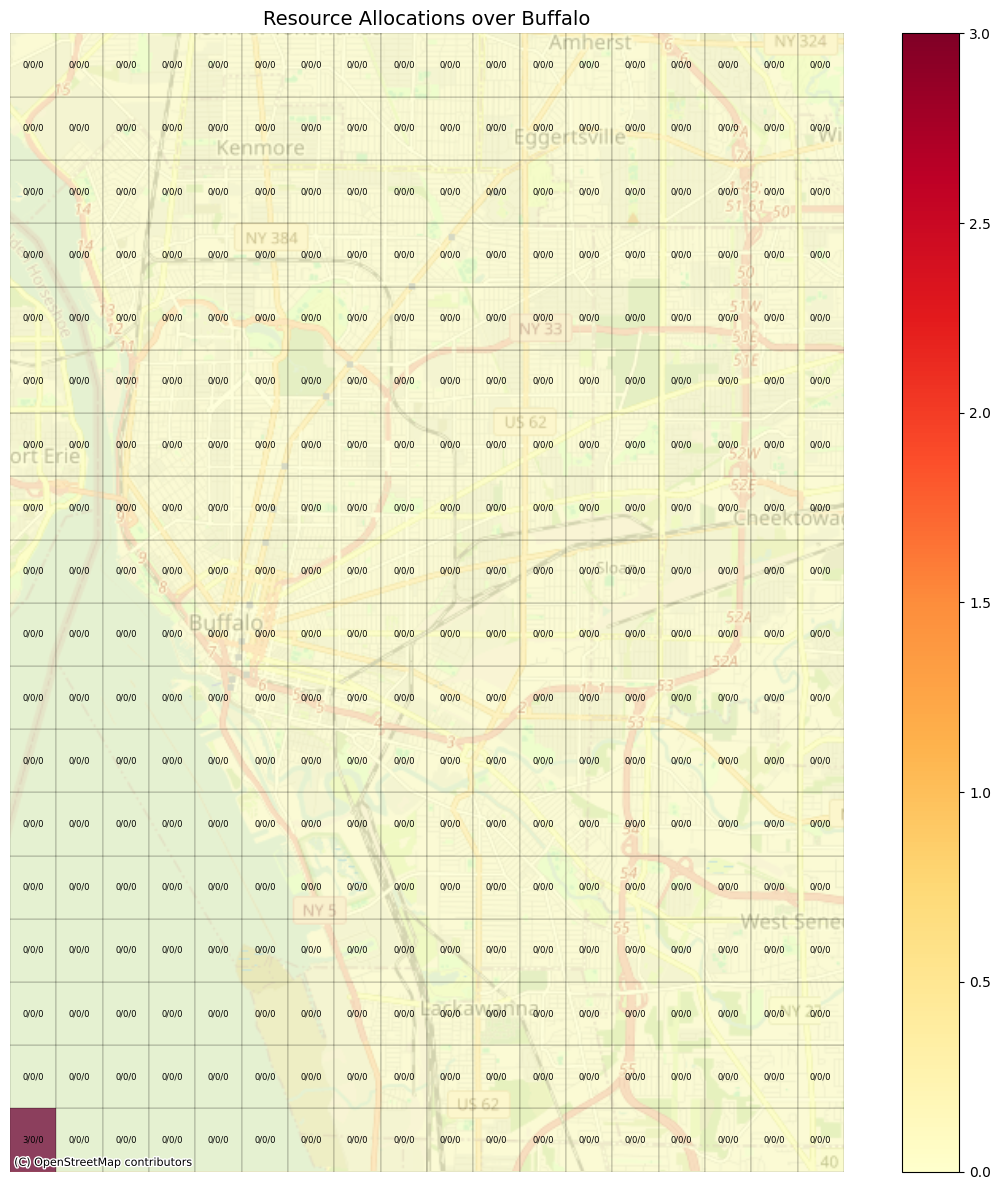

In [ ]:
plot_allocations_on_buffalo_map(grid, last_allocations)


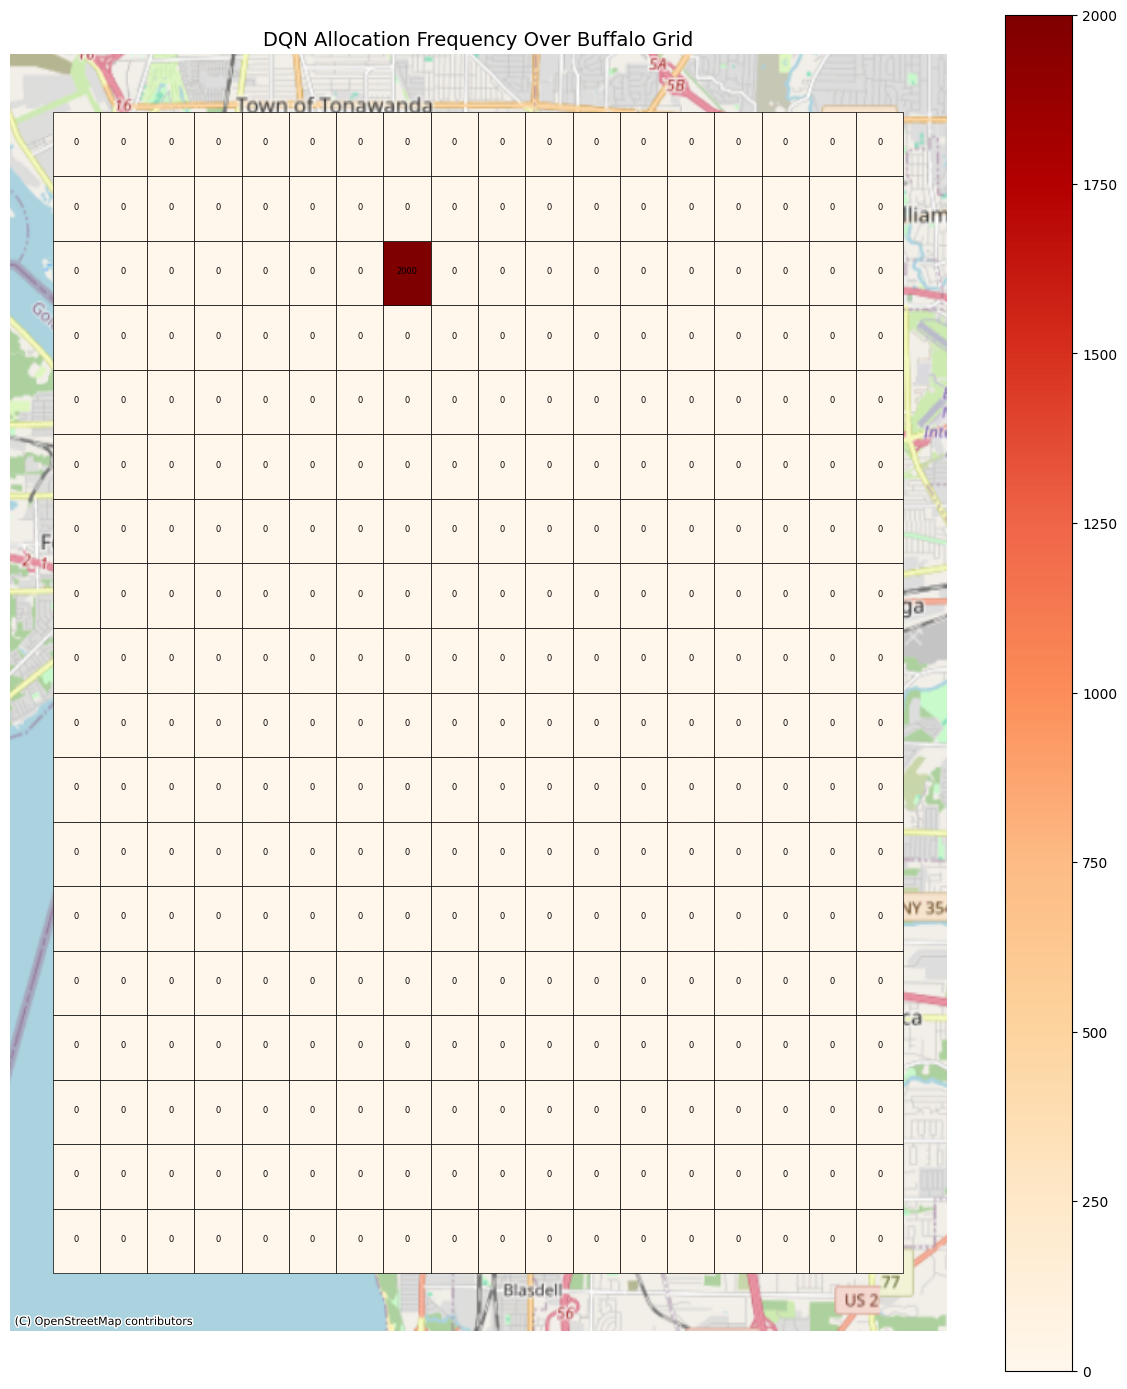

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# initializing allocation count matrix
allocation_counts = np.zeros(env.resources_allocated.shape[0]) 

# evaluating agent and count allocations
for ep in range(10):
    obs, _ = env.reset()
    done = False

    while not done:
        with torch.no_grad():
            state_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            q_type, q_res, q_cell = agent.policy_net(state_tensor)
            action_type = q_type.argmax(1).item()
            action_res = q_res.argmax(1).item()
            action_cell = q_cell.argmax(1).item()

        obs, reward, terminated, truncated, info = env.step([action_type, action_res, action_cell])
        done = terminated or truncated

        if action_type == 0:  
            allocation_counts[action_cell] += 1
used_grid_ids = env.probability_data.index  

# creating a series with allocation counts indexed by grid_id
alloc_series = pd.Series(allocation_counts, index=used_grid_ids, name="allocations")

# joining with full grid geodataframe
grid_with_counts = grid.set_index("grid_id").join(alloc_series).fillna(0).reset_index()

# plotting
fig, ax = plt.subplots(figsize=(12, 14))
grid_with_counts.plot(
    column="allocations",
    ax=ax,
    legend=True,
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.5,
)

# labelling each cell with count
for _, row in grid_with_counts.iterrows():
    center = row.geometry.centroid
    ax.text(center.x, center.y, f"{int(row.allocations)}", fontsize=6, ha="center")

import contextily as ctx
ctx.add_basemap(ax, crs=grid_with_counts.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("DQN Allocation Frequency Over Buffalo Grid", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()


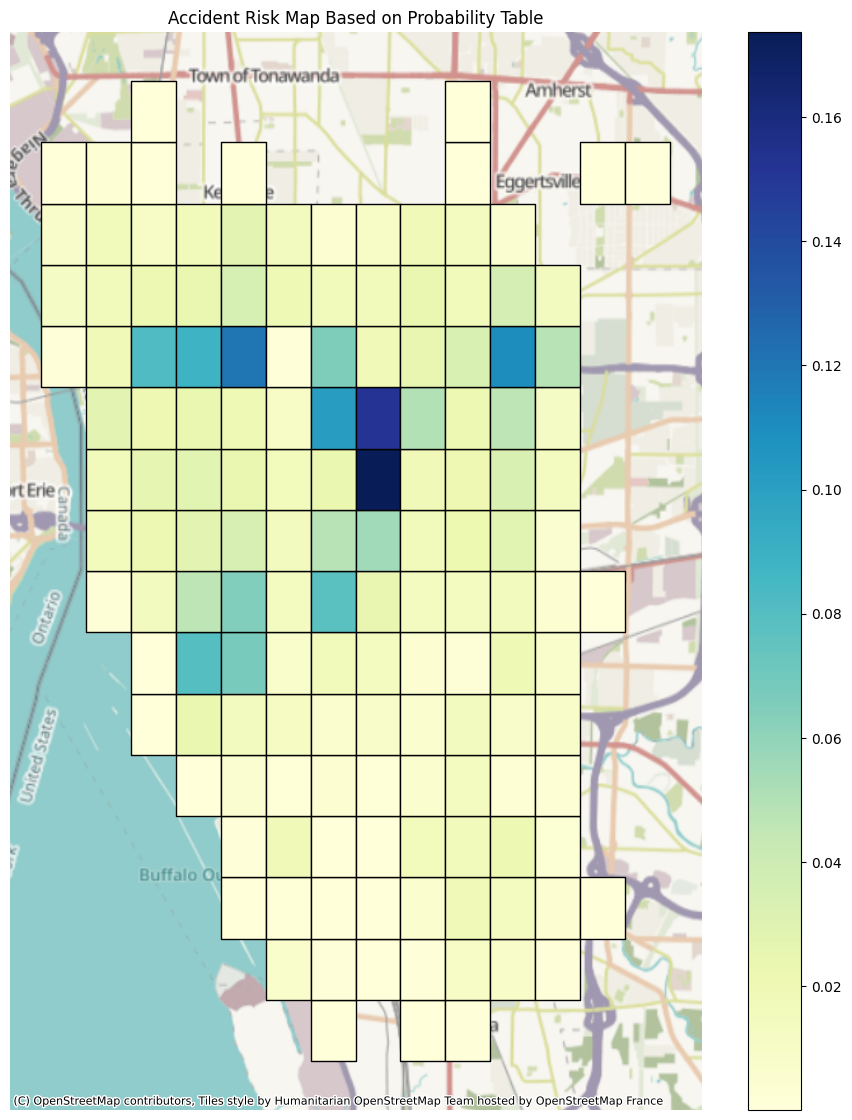

In [ ]:
grid_with_probs = grid.set_index("grid_id").join(env.probability_data.sum(axis=1).rename("accident_risk")).reset_index()

fig, ax = plt.subplots(figsize=(12, 14))
grid_with_probs.plot(column="accident_risk", ax=ax, legend=True, cmap="YlGnBu", edgecolor="black")
ctx.add_basemap(ax, crs=grid_with_probs.crs.to_string())
ax.set_title("Accident Risk Map Based on Probability Table")
ax.axis("off")
plt.show()
